# Computer Vision: Project 2: Joint Detection of AI-Generated Images and Post-Processing Alterations in Real-World Scenarios

## By Angela Petkova (2288299) and Oliver van Douveren (2285369)

## Imports

In [ ]:
# Library imports: all the needed packages
import os
import copy
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.notebook import tqdm
from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights
import shutil
import numpy as np
import random
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from google.colab import drive
from PIL import ImageGrab, Image
from sklearn.metrics import confusion_matrix, classification_report
Image.MAX_IMAGE_PIXELS = None
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights

## Globals

In [ ]:
# Global variables

random.seed(42)

## Labels
TASK1_MAP = {"real": 0, "ai": 1}
TASK2_MAP = {"original": 0, "transfer": 1, "redigital": 2}

TRANSFORMS = ["original", "transfer", "redigital"]
AUTH_CLASSES = ["real", "ai"]

## Losses for the Tasks
criterion_auth = nn.CrossEntropyLoss()
criterion_transform = nn.CrossEntropyLoss()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Glolbal Constants
resize_image_size = 380
global_batch_size = 16

## Utils

### Model Training functions

In [ ]:
def train_multitask_model(auth_loss_weight, trans_loss_weight,save_path,
    num_epochs=15,
    learning_rate=0.0001,
    weight_decay=1e-4,
    start_epoch=0,
    best_combined_acc=0.0,
    best_auth_acc=0.0,
    best_trans_acc=0.0,
    best_epoch=0,
    resume_path=None
):
    # Load Model
    model = MultiTaskDetectorEfficient().to(device)

    # Setup Optimizer
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    # Cosine Annealing scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=num_epochs
    )

    # Load checkpoint if continuing training
    if resume_path is not None:
       # Load the information from the last run
        checkpoint = torch.load(resume_path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])


        start_epoch = checkpoint["epoch"]
        best_combined_acc = checkpoint["best_combined_acc"]
        best_auth_acc = checkpoint["best_auth_acc"]
        best_trans_acc = checkpoint["best_trans_acc"]
        best_epoch = checkpoint["best_epoch"]

        print(f"Resumed from checkpoint: {resume_path}")
        print(f"Resuming from Epoch {start_epoch + 1}")
        print(f"Best Combined Acc so far: {best_combined_acc:.2f}%")

    print(f"Starting from Epoch {start_epoch + 1}")
    print(f"Learning Rate caught up to: {scheduler.get_last_lr()[0]:.6f}")
    print(f"Auth loss weight: {auth_loss_weight}")
    print(f"Transform loss weight: {trans_loss_weight}")

    # Epoch progress bar
    epoch_bar = tqdm(range(start_epoch, num_epochs), desc="Training")

    # Loop over epochs:
    for epoch in epoch_bar:
        # 1. Training
        model.train()
        running_loss = 0.0

        batch_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)

        # Loop trough training batch
        for images, auth_labels, trans_labels in batch_bar:
            images = images.to(device)
            auth_labels = auth_labels.to(device)
            trans_labels = trans_labels.to(device)

            # Reset gradients
            optimizer.zero_grad()

            # Forward pass
            out_auth, out_transform = model(images)

            # Calculate seperate losses
            loss_auth = criterion_auth(out_auth, auth_labels)
            loss_transform = criterion_transform(out_transform, trans_labels)

            # Combine both losses
            total_loss = (auth_loss_weight * loss_auth) + (trans_loss_weight * loss_transform)

            # Backpropagation
            total_loss.backward()

            # Update model weights
            optimizer.step()

            # Batch loss
            running_loss += total_loss.item()
            # To update progress bar
            batch_bar.set_postfix({'Loss': f"{total_loss.item():.4f}"})

        avg_train_loss = running_loss / len(train_loader)

        # 2. Validation
        model.eval()
        # To track validation accuracy
        auth_correct, transform_correct, total_samples = 0, 0, 0

        # No training, so no need to compute gradients
        with torch.no_grad():
          # Validation progress bar
            val_bar = tqdm(
                val_loader,
                desc=f"Epoch {epoch+1}/{num_epochs} [Eval]",
                leave=False
            )

            # Loop trough validation batches
            for images, auth_labels, trans_labels in val_bar:
                images = images.to(device)
                auth_labels = auth_labels.to(device)
                trans_labels = trans_labels.to(device)

                # Forward pass for predictions
                out_auth, out_transform = model(images)

                # Convert model logits into class predictions by selecting the class with the highest score
                auth_preds = torch.argmax(out_auth, dim=1)
                transform_preds = torch.argmax(out_transform, dim=1)

                # Count correct predictions
                auth_correct += (auth_preds == auth_labels).sum().item()
                transform_correct += (transform_preds == trans_labels).sum().item()
                total_samples += auth_labels.size(0)

        # Turn into %
        auth_acc = (auth_correct / total_samples) * 100
        trans_acc = (transform_correct / total_samples) * 100
        combined_acc = (auth_acc + trans_acc) / 2
        print(
            f"\nEpoch {epoch+1} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Auth Acc: {auth_acc:.2f}% | "
            f"Val Trans Acc: {trans_acc:.2f}%"
        )

        # 1. Prepare the base state dictionary
        checkpoint = {
              "epoch": epoch + 1,
              "model_state_dict": copy.deepcopy(model.state_dict()),
              "optimizer_state_dict": optimizer.state_dict(),
              "scheduler_state_dict": scheduler.state_dict(),
              "best_combined_acc": best_combined_acc,
              "best_auth_acc": best_auth_acc,
              "best_trans_acc": best_trans_acc,
              "best_epoch": best_epoch,
              "auth_loss_weight": auth_loss_weight,
              "trans_loss_weight": trans_loss_weight,
              "learning_rate": learning_rate,
              "weight_decay": weight_decay
          }

        # 2. Check and save the "best" model FIRST
        if combined_acc > best_combined_acc:
          print(f"New best model found! (Combined Acc: {combined_acc:.2f}%). Saving to Drive")

          best_combined_acc = combined_acc
          best_auth_acc = auth_acc
          best_trans_acc = trans_acc
          best_epoch = epoch + 1

          # Update the checkpoint dictionary with the newly found bests
          checkpoint["best_combined_acc"] = best_combined_acc
          checkpoint["best_auth_acc"] = best_auth_acc
          checkpoint["best_trans_acc"] = best_trans_acc
          checkpoint["best_epoch"] = best_epoch

          torch.save(checkpoint, save_path)

        # 3. save the "latest" state, ensuring it has the most up-to-date 'best' trackers
        latest_path = save_path.replace(".pth", "_latest.pth")
        torch.save(checkpoint, latest_path)

        # Update progress bar
        epoch_bar.set_postfix({'Best Acc': f"{best_combined_acc:.2f}%"})

        scheduler.step()

    print("\nTraining Complete!")
    print(f"Auth Loss Weight: {auth_loss_weight}")
    print(f"Transform Loss Weight: {trans_loss_weight}")
    print(f"Best Epoch: {best_epoch}")
    print(f"Best Combined Acc: {best_combined_acc:.2f}%")
    print(f"Auth Acc at Best: {best_auth_acc:.2f}%")
    print(f"Transform Acc at Best: {best_trans_acc:.2f}%")
    print(f"Saved to: {save_path}")

    return {
        "auth_loss_weight": auth_loss_weight,
        "trans_loss_weight": trans_loss_weight,
        "best_epoch": best_epoch,
        "best_combined_acc": best_combined_acc,
        "best_auth_acc": best_auth_acc,
        "best_trans_acc": best_trans_acc,
        "save_path": save_path
    }

In [ ]:
def train_transform_model(save_path, num_epochs=15, learning_rate=0.0001, weight_decay=1e-4, resume_path=None):
    model = TransformClassifierEfficient().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    start_epoch = 0
    best_trans_acc = 0.0

    if resume_path is not None:
        checkpoint = torch.load(resume_path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        start_epoch = checkpoint["epoch"]
        best_trans_acc = checkpoint["best_trans_acc"]

    epoch_bar = tqdm(range(start_epoch, num_epochs), desc="Training Transform Classifier")

    for epoch in epoch_bar:
        model.train()
        running_loss = 0.0
        batch_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)

        for images, _, trans_labels in batch_bar: # Notice the '_' ignoring auth_labels
            images, trans_labels = images.to(device), trans_labels.to(device)

            optimizer.zero_grad()
            out_transform = model(images)
            loss = criterion_transform(out_transform, trans_labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            batch_bar.set_postfix({'Loss': f"{loss.item():.4f}"})

        avg_train_loss = running_loss / len(train_loader)

        # VALIDATION
        model.eval()
        transform_correct, total_samples = 0, 0

        with torch.no_grad():
            val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Eval]", leave=False)
            for images, _, trans_labels in val_bar:
                images, trans_labels = images.to(device), trans_labels.to(device)

                out_transform = model(images)
                transform_preds = torch.argmax(out_transform, dim=1)

                transform_correct += (transform_preds == trans_labels).sum().item()
                total_samples += trans_labels.size(0)

        trans_acc = (transform_correct / total_samples) * 100
        print(f"\nEpoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Trans Acc: {trans_acc:.2f}%")

        # SAVE CHECKPOINTS ---
        checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": copy.deepcopy(model.state_dict()),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_trans_acc": best_trans_acc,
        }

        if trans_acc > best_trans_acc:
            print(f"New best model found! (Trans Acc: {trans_acc:.2f}%). Saving...")
            best_trans_acc = trans_acc
            checkpoint["best_trans_acc"] = best_trans_acc
            torch.save(checkpoint, save_path)

        latest_path = save_path.replace(".pth", "_latest.pth")
        torch.save(checkpoint, latest_path)

        epoch_bar.set_postfix({'Best Acc': f"{best_trans_acc:.2f}%"})
        scheduler.step()

    return {"best_trans_acc": best_trans_acc, "save_path": save_path}

In [1]:
def train_authenticator_model(save_path, num_epochs=15, learning_rate=0.0001, weight_decay=1e-4, resume_path=None):
    model = AuthenticatorEfficient().to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay) #Normal Optimizer

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)


    if resume_path is not None:
        checkpoint = torch.load(resume_path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        start_epoch = checkpoint["epoch"]
        best_auth_acc = checkpoint["best_auth_acc"]
    else:
        start_epoch = 0
        best_auth_acc = 0.0

    epoch_bar = tqdm(range(start_epoch, num_epochs), desc="Training Authenticator")


    for epoch in epoch_bar:
        model.train()
        running_loss = 0.0
        batch_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)

        for images, auth_labels, _ in batch_bar:
            images, auth_labels = images.to(device), auth_labels.to(device)

            optimizer.zero_grad()
            out_auth = model(images)
            loss = criterion_auth(out_auth, auth_labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            batch_bar.set_postfix({'Loss': f"{loss.item():.4f}"})

        avg_train_loss = running_loss / len(train_loader)

        # VALIDATION
        model.eval()
        auth_correct, total_samples = 0, 0

        with torch.no_grad():
            val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Eval]", leave=False)
            for images, auth_labels, _ in val_bar:
                images, auth_labels = images.to(device), auth_labels.to(device)

                out_auth = model(images)
                auth_preds = torch.argmax(out_auth, dim=1)

                auth_correct += (auth_preds == auth_labels).sum().item()
                total_samples += auth_labels.size(0)

        auth_acc = (auth_correct / total_samples) * 100
        print(f"\nEpoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Auth Acc: {auth_acc:.2f}%")

        # CHECKPOINTS
        checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": copy.deepcopy(model.state_dict()),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_auth_acc": best_auth_acc,
        }

        if auth_acc > best_auth_acc:
            print(f"New best model found! (Auth Acc: {auth_acc:.2f}%). Saving...")
            best_auth_acc = auth_acc
            checkpoint["best_auth_acc"] = best_auth_acc
            torch.save(checkpoint, save_path)

        latest_path = save_path.replace(".pth", "_latest.pth")
        torch.save(checkpoint, latest_path)

        epoch_bar.set_postfix({'Best Acc': f"{best_auth_acc:.2f}%"})
        scheduler.step()

    return {"best_auth_acc": best_auth_acc, "save_path": save_path}

### Evaluation functions

In [ ]:
def evaluate_predictions(model, dataloader, device):
  # Use global variables to reverse the label maps so numeric labels can be displayed as readable class names
    auth_label_names = {v: k for k, v in TASK1_MAP.items()}
    transform_label_names = {v: k for k, v in TASK2_MAP.items()}

    model = model.to(device)
    model.eval()

    # To store the results for each image
    # For each image will be stored :
                      # true auth label
                      # predicted auth label
                      # true transform label
                      # predicted transform label
                      # whether auth prediction was correct
                      # whether transform prediction was correct
    records = []

    # Only evaluation, so no need to compute gradients
    with torch.no_grad():
      # Loop trough the batches
      for images, auth_labels, trans_labels in tqdm(dataloader, desc="Evaluating"):
            images = images.to(device)
            auth_labels = auth_labels.to(device)
            trans_labels = trans_labels.to(device)

            # Forward pass for models predictions
            out_auth, out_transform = model(images)

            # Convert logits into predicted class labels
            auth_preds = torch.argmax(out_auth, dim=1)
            trans_preds = torch.argmax(out_transform, dim=1)

            # Loop over every image in the current batch
            for i in range(images.size(0)):
                true_auth = int(auth_labels[i].cpu())
                pred_auth = int(auth_preds[i].cpu())
                true_trans = int(trans_labels[i].cpu())
                pred_trans = int(trans_preds[i].cpu())

                records.append({
                    "true_auth_label": true_auth,
                    "pred_auth_label": pred_auth,
                    "true_auth_name": auth_label_names.get(true_auth, str(true_auth)),
                    "pred_auth_name": auth_label_names.get(pred_auth, str(pred_auth)),

                    "true_transform_label": true_trans,
                    "pred_transform_label": pred_trans,
                    "true_transform_name": transform_label_names.get(true_trans, str(true_trans)),
                    "pred_transform_name": transform_label_names.get(pred_trans, str(pred_trans)),

                    "auth_correct": true_auth == pred_auth,
                    "transform_correct": true_trans == pred_trans
                })

    df = pd.DataFrame(records)

    # Calculate overal accuracy
    overall_auth_acc = df["auth_correct"].mean() * 100
    overall_transform_acc = df["transform_correct"].mean() * 100

    print("Overall accuracy ")
    print(f"Ai/original accuracy:        {overall_auth_acc:.2f}%")
    print(f"Transformation accuracy:   {overall_transform_acc:.2f}%")
    print()

    # Auth accuracy per transformation
    print("Ai/original accuracy by transformation type")

    auth_by_transform = (
        df.groupby("true_transform_name")
        .agg(
            num_samples=("auth_correct", "count"),
            auth_accuracy=("auth_correct", "mean")
        )
        .reset_index()
    )
    auth_by_transform["auth_accuracy"] *= 100
    auth_by_transform = auth_by_transform.sort_values("auth_accuracy")
    display(auth_by_transform)

    # Auth accuracy per transformation and original/ai class
    print("Original/ai accuracy by transformation type and true class")

    auth_by_transform_and_class = (
        df.groupby(["true_transform_name", "true_auth_name"])
        .agg(
            num_samples=("auth_correct", "count"),
            auth_accuracy=("auth_correct", "mean")
        )
        .reset_index()
    )

    auth_by_transform_and_class["auth_accuracy"] *= 100
    auth_by_transform_and_class = auth_by_transform_and_class.sort_values(
        ["true_transform_name", "auth_accuracy"]
    )

    display(auth_by_transform_and_class)

    #  Pivot table: easier to read in report
    print("========== Pivot Table: Auth Accuracy ==========")

    pivot_acc = auth_by_transform_and_class.pivot(
        index="true_transform_name",
        columns="true_auth_name",
        values="auth_accuracy"
    )

    display(pivot_acc)

    # Which transformation type makes the real/fake detector perform worst.
    worst_row = auth_by_transform.iloc[0]

    print("========== Which transformation type makes the real/fake detector perform worst ==========")
    print(
        f"The lowest real/fake detection accuracy occurs for "
        f"{worst_row['true_transform_name']} images: "
        f"{worst_row['auth_accuracy']:.2f}% accuracy "
        f"over {int(worst_row['num_samples'])} samples.")
    print()

    # Confusion matrices
    print("========== Real/Fake Confusion Matrix ==========")

    auth_cm = confusion_matrix(
        df["true_auth_label"],
        df["pred_auth_label"],
        labels=sorted(auth_label_names.keys())
    )

    auth_cm_df = pd.DataFrame(
        auth_cm,
        index=[f"True {auth_label_names[i]}" for i in sorted(auth_label_names.keys())],
        columns=[f"Pred {auth_label_names[i]}" for i in sorted(auth_label_names.keys())]
    )

    display(auth_cm_df)

    print("========== Transformation Confusion Matrix ==========")

    transform_cm = confusion_matrix(
        df["true_transform_label"],
        df["pred_transform_label"],
        labels=sorted(transform_label_names.keys())
    )

    transform_cm_df = pd.DataFrame(
        transform_cm,
        index=[f"True {transform_label_names[i]}" for i in sorted(transform_label_names.keys())],
        columns=[f"Pred {transform_label_names[i]}" for i in sorted(transform_label_names.keys())]
    )

    display(transform_cm_df)

    print("========== Transformation Confusion Matrix (Normalized) ==========")
    # This shows percentages instead of raw counts
    transform_cm_norm = transform_cm.astype('float') / transform_cm.sum(axis=1)[:, np.newaxis]
    display(pd.DataFrame(transform_cm_norm, index=transform_cm_df.index, columns=transform_cm_df.columns))

    return {
        "predictions_df": df,
        "auth_by_transform": auth_by_transform,
        "auth_by_transform_and_class": auth_by_transform_and_class,
        "pivot_acc": pivot_acc,
        "auth_confusion_matrix": auth_cm_df,
        "transform_confusion_matrix": transform_cm_df,
        "overall_auth_acc": overall_auth_acc,
        "overall_transform_acc": overall_transform_acc
    }

In [ ]:
def evaluate_predictions_auth(model, dataloader, device):
  # Use global variables to reverse the label maps so numeric labels can be displayed as readable class names
    auth_label_names = {v: k for k, v in TASK1_MAP.items()}
    transform_label_names = {v: k for k, v in TASK2_MAP.items()}

    model = model.to(device)
    model.eval()

    # To store the results for each image
    # For each image will be stored :
                      # true auth label
                      # predicted auth label
                      # true transform label
                      # predicted transform label
                      # whether auth prediction was correct
                      # whether transform prediction was correct
    records = []

    # Only evaluation, so no need to compute gradients
    with torch.no_grad():
      # Loop trough the batches
      for images, auth_labels, trans_labels in tqdm(dataloader, desc="Evaluating"):
            images = images.to(device)
            auth_labels = auth_labels.to(device)
            trans_labels = trans_labels.to(device)

            # Forward pass for models predictions
            out_auth = model(images)

            # Convert logits into predicted class labels
            auth_preds = torch.argmax(out_auth, dim=1)
            trans_preds = torch.argmax(out_auth, dim=1)

            # Loop over every image in the current batch
            for i in range(images.size(0)):
                true_auth = int(auth_labels[i].cpu())
                pred_auth = int(auth_preds[i].cpu())
                true_trans = int(trans_labels[i].cpu())
                pred_trans = int(trans_preds[i].cpu())

                records.append({
                    "true_auth_label": true_auth,
                    "pred_auth_label": pred_auth,
                    "true_auth_name": auth_label_names.get(true_auth, str(true_auth)),
                    "pred_auth_name": auth_label_names.get(pred_auth, str(pred_auth)),

                    "true_transform_label": true_trans,
                    "pred_transform_label": pred_trans,
                    "true_transform_name": transform_label_names.get(true_trans, str(true_trans)),
                    "pred_transform_name": transform_label_names.get(pred_trans, str(pred_trans)),

                    "auth_correct": true_auth == pred_auth,
                    "transform_correct": true_trans == pred_trans
                })

    df = pd.DataFrame(records)

    # Calculate overal accuracy
    overall_auth_acc = df["auth_correct"].mean() * 100

    print(f"Ai/original accuracy:        {overall_auth_acc:.2f}%")
    print()

    # Auth accuracy per transformation
    print("Ai/original accuracy by transformation type")

    auth_by_transform = (
        df.groupby("true_transform_name")
        .agg(
            num_samples=("auth_correct", "count"),
            auth_accuracy=("auth_correct", "mean")
        )
        .reset_index()
    )
    auth_by_transform["auth_accuracy"] *= 100
    auth_by_transform = auth_by_transform.sort_values("auth_accuracy")
    display(auth_by_transform)

    # Auth accuracy per transformation and original/ai class
    print("Original/ai accuracy by transformation type and true class")

    auth_by_transform_and_class = (
        df.groupby(["true_transform_name", "true_auth_name"])
        .agg(
            num_samples=("auth_correct", "count"),
            auth_accuracy=("auth_correct", "mean")
        )
        .reset_index()
    )

    auth_by_transform_and_class["auth_accuracy"] *= 100
    auth_by_transform_and_class = auth_by_transform_and_class.sort_values(
        ["true_transform_name", "auth_accuracy"]
    )

    display(auth_by_transform_and_class)

    #  Pivot table: easier to read in report
    print("========== Pivot Table: Auth Accuracy ==========")

    pivot_acc = auth_by_transform_and_class.pivot(
        index="true_transform_name",
        columns="true_auth_name",
        values="auth_accuracy"
    )

    display(pivot_acc)

    # Which transformation type makes the real/fake detector perform worst.
    worst_row = auth_by_transform.iloc[0]

    print("========== Which transformation type makes the real/fake detector perform worst ==========")
    print(
        f"The lowest real/fake detection accuracy occurs for "
        f"{worst_row['true_transform_name']} images: "
        f"{worst_row['auth_accuracy']:.2f}% accuracy "
        f"over {int(worst_row['num_samples'])} samples.")
    print()

    # -------------------------
    # Confusion matrices
    # -------------------------
    print("========== Real/Fake Confusion Matrix ==========")

    auth_cm = confusion_matrix(
        df["true_auth_label"],
        df["pred_auth_label"],
        labels=sorted(auth_label_names.keys())
    )

    auth_cm_df = pd.DataFrame(
        auth_cm,
        index=[f"True {auth_label_names[i]}" for i in sorted(auth_label_names.keys())],
        columns=[f"Pred {auth_label_names[i]}" for i in sorted(auth_label_names.keys())]
    )

    display(auth_cm_df)

In [ ]:
def evaluate_predictions_trans(model, dataloader, device):
  # Use global variables to reverse the label maps so numeric labels can be displayed as readable class names
    auth_label_names = {v: k for k, v in TASK1_MAP.items()}
    transform_label_names = {v: k for k, v in TASK2_MAP.items()}

    model = model.to(device)
    model.eval()

    # To store the results for each image
    # For each image will be stored :
                      # true auth label
                      # predicted auth label
                      # true transform label
                      # predicted transform label
                      # whether auth prediction was correct
                      # whether transform prediction was correct
    records = []

    # Only evaluation, so no need to compute gradients
    with torch.no_grad():
      # Loop trough the batches
      for images, auth_labels, trans_labels in tqdm(dataloader, desc="Evaluating"):
            images = images.to(device)
            auth_labels = auth_labels.to(device)
            trans_labels = trans_labels.to(device)

            # Forward pass for models predictions
            out_transform = model(images)

            # Convert logits into predicted class labels
            auth_preds = torch.argmax(out_transform, dim=1)
            trans_preds = torch.argmax(out_transform, dim=1)

            # Loop over every image in the current batch
            for i in range(images.size(0)):
                true_auth = int(auth_labels[i].cpu())
                pred_auth = int(auth_preds[i].cpu())
                true_trans = int(trans_labels[i].cpu())
                pred_trans = int(trans_preds[i].cpu())

                records.append({
                    "true_auth_label": true_auth,
                    "pred_auth_label": pred_auth,
                    "true_auth_name": auth_label_names.get(true_auth, str(true_auth)),
                    "pred_auth_name": auth_label_names.get(pred_auth, str(pred_auth)),

                    "true_transform_label": true_trans,
                    "pred_transform_label": pred_trans,
                    "true_transform_name": transform_label_names.get(true_trans, str(true_trans)),
                    "pred_transform_name": transform_label_names.get(pred_trans, str(pred_trans)),

                    "auth_correct": true_auth == pred_auth,
                    "transform_correct": true_trans == pred_trans
                })

    df = pd.DataFrame(records)

    # Calculate overal accuracy
    overall_transform_acc = df["transform_correct"].mean() * 100

    print("Overall accuracy ")
    print(f"Transformation accuracy:   {overall_transform_acc:.2f}%")
    print()

    print("========== Transformation Confusion Matrix ==========")

    transform_cm = confusion_matrix(
        df["true_transform_label"],
        df["pred_transform_label"],
        labels=sorted(transform_label_names.keys())
    )

    transform_cm_df = pd.DataFrame(
        transform_cm,
        index=[f"True {transform_label_names[i]}" for i in sorted(transform_label_names.keys())],
        columns=[f"Pred {transform_label_names[i]}" for i in sorted(transform_label_names.keys())]
    )

    display(transform_cm_df)

    print("========== Transformation Confusion Matrix (Normalized) ==========")
    # This shows percentages instead of raw counts
    transform_cm_norm = transform_cm.astype('float') / transform_cm.sum(axis=1)[:, np.newaxis]
    display(pd.DataFrame(transform_cm_norm, index=transform_cm_df.index, columns=transform_cm_df.columns))

## Data : everything related to data management

### 1. Data preparation and subset selection

We will be using the free Colab environment, because of the free GPU availability. The GPU is NVIDIA Tesla T4 GPU (15.0 GB VRAM), system memory is 12.7 GB, and there is 113 GB Available Disk Space for storage.

Since each image was approximately 1.7 MB, the full subset required around 30.6 GB (18,000 x 1.7 MB) of disk space. This was manageable within the available Colab runtime storage, while still leaving space for model checkpoints, logs, cached files, and training outputs.

In [ ]:
!df -h
!free -h
!nvidia-smi

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   48G   66G  42% /
tmpfs            64M     0   64M   0% /dev
shm             5.7G     0  5.7G   0% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
/dev/sda1       119G   52G   67G  44% /opt/bin/.nvidia
tmpfs           6.4G   32K  6.4G   1% /var/colab
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware
               total        used        free      shared  buff/cache   available
Mem:            12Gi       679Mi       8.6Gi       2.0Mi       3.4Gi        11Gi
Swap:             0B          0B          0B
Wed Jun 10 09:29:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------

In [ ]:
# TO DO ONCE: Dawnload entire dataset
# Download dataset
!wget "https://zenodo.org/records/14963880/files/RRDataset_test.tar.gz?download=1" -O RRDataset_test.tar.gz

# Get contents
!tar -xzf RRDataset_test.tar.gz

# Delete the downloaded archive
!rm RRDataset_test.tar.gz

--2026-06-03 08:21:04--  https://zenodo.org/records/14963880/files/RRDataset_test.tar.gz?download=1
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 188.184.103.118, 137.138.153.219, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20117869400 (19G) [application/octet-stream]
Saving to: ‘RRDataset_test.tar.gz’

RRDataset_test.tar. 100%[===================>]  18.74G  1.87MB/s    in 96m 25s 

2026-06-03 09:57:30 (3.32 MB/s) - ‘RRDataset_test.tar.gz’ saved [20117869400/20117869400]



To avoid data leakage we group pictures togheter that are the same (same ID) in the training set, validation set and test set. Without this, 3 different versions of the same image could end up in the training, validation set and test set.

In [ ]:
# Extract nummer at the end of each image redigital_real_009999.jpg becomes 009999 = the ID
# This is called for every image
def get_scene_id(path):
    return path.stem.split("_")[-1]

# A family of pictures is the 3 transformations (original, transfer, and redigital) of the same picture (same ID)
# This function creates a dictionary where each key is a unique family ID (for example ai_009999 or real_009999,it depends on the authenticity label (ai or original))
# Each value stores:
# - the authenticity class: real or ai
# - the scene ID
# - the path to the original image
# - the path to the transfer image
# - the path to the redigital image
def collect_complete_scene_families(source_dir):
    # Convert the folder path into a Path object
    source_dir = Path(source_dir)
    families = defaultdict(dict)

    # Loop over transformation types
    for transform_name in TRANSFORMS:
      # Loop over authenticity classes: ai or real
        for auth_name in AUTH_CLASSES:
          # Build path to the folder
            folder = source_dir / transform_name / auth_name

            # Loop over all images in this folder
            for img_path in folder.glob("*.*"):
                scene_id = get_scene_id(img_path)
                # Create a unique key for the image family (ai_ID or real_ID)
                family_key = f"{auth_name}_{scene_id}"

                # Store information about the family
                families[family_key]["auth_name"] = auth_name
                families[family_key]["scene_id"] = scene_id
                # Make file path to image
                # for example: families["real_009999"]["original"] = original_real_009999.jpg
                families[family_key][transform_name] = img_path

    complete_families = []

    # Loop trough each family to check if it has all 3 transforms so only complete families are kept
    for family_key, info in families.items():
        has_all_transforms = all(t in info for t in TRANSFORMS)

        if has_all_transforms:
            complete_families.append(info)

    return complete_families

In [ ]:
# A homework requirement is to have a balanced dataset, so we need to create same number of real families and AI families in our subset of data
# (Each selected family is already balanced = the original image, the redigitalized version and the transfered version)
def create_balanced_subset(source_dir,dest_dir,max_scenes_per_class=3000):
    # Convert the folder paths into Path objects.
    source_dir = Path(source_dir)
    dest_dir = Path(dest_dir)

    # Get all families
    complete_families = collect_complete_scene_families(source_dir)
    # Filter the families based on if their ai or real
    real_families = [f for f in complete_families if f["auth_name"] == "real"]
    ai_families = [f for f in complete_families if f["auth_name"] == "ai"]

    # Decide how many families will be put in both classes
    # This was done because there were less AI generated images, so we take the minimum
    scenes_per_class = min(
        len(real_families),
        len(ai_families),
        max_scenes_per_class
    )

    print(f"Using {scenes_per_class} scenes per class")
    print(f"Total scenes: {scenes_per_class * 2}")
    print(f"Total images: {scenes_per_class * 2 * 3}")

    # Randomly select real and ai families
    selected_real = random.sample(real_families, scenes_per_class)
    selected_ai = random.sample(ai_families, scenes_per_class)
    # Combine and shuffle
    selected_families = selected_real + selected_ai
    random.shuffle(selected_families)

    # List of dictionaries (1 for every copied image) with 6 entries per dictionary
    records = []

    # For every image collect the filepath, the scene_id, the labels and name the 2 prediction tasks
    for family in selected_families:
        auth_name = family["auth_name"]
        scene_id = family["scene_id"]
        auth_label = TASK1_MAP[auth_name]

        for transform_name in TRANSFORMS:
            src_path = family[transform_name]
            transform_label = TASK2_MAP[transform_name]

            dest_folder = dest_dir / transform_name / auth_name
            dest_folder.mkdir(parents=True, exist_ok=True)

            dest_path = dest_folder / src_path.name
            # File path to copied image
            shutil.copy2(src_path, dest_path)

            records.append({
                "filepath": str(dest_path),
                "scene_id": f"{auth_name}_{scene_id}",
                "auth_name": auth_name,
                "auth_label": auth_label,
                "transform_name": transform_name,
                "transform_label": transform_label
            })

    # Convert to dataframe where each entry is 1 copied image
    df = pd.DataFrame(records)
    return df

In [ ]:
# Create subset of 3,000 families for both ai and real images
subset_df = create_balanced_subset(
    source_dir="/content/RRDataset_final",
    dest_dir="/content/RRDataset_Subset",
    max_scenes_per_class=3000,
    seed=42
)

Using 3000 scenes per class
Total scenes: 6000
Total images: 18000


In [ ]:
print("Full subset size:", len(subset_df))

print("\nTask 1 balance:")
print(subset_df["auth_name"].value_counts())

print("\nTask 2 balance:")
print(subset_df["transform_name"].value_counts())

print("\nJoint balance:")
print(pd.crosstab(subset_df["auth_name"], subset_df["transform_name"]))

Full subset size: 18000

Task 1 balance:
auth_name
real    9000
ai      9000
Name: count, dtype: int64

Task 2 balance:
transform_name
original     6000
transfer     6000
redigital    6000
Name: count, dtype: int64

Joint balance:
transform_name  original  redigital  transfer
auth_name                                    
ai                  3000       3000      3000
real                3000       3000      3000


Now that the subset of families of images is created, the families will be further split up into a training (80%), validation (10%) and test set (10%).

In [ ]:
# Split families, not images
def create_train_val_test_splits(subset_df):
  # Create one row per family
    scene_df = subset_df[["scene_id", "auth_label", "auth_name"]].drop_duplicates()
    # Train set
    train_scenes, temp_scenes = train_test_split(
        scene_df,
        test_size=0.20,
        random_state=42,
        stratify=scene_df["auth_label"]
    )
    # Validation and test set
    val_scenes, test_scenes = train_test_split(
        temp_scenes,
        test_size=0.50,
        random_state=42,
        stratify=temp_scenes["auth_label"]
    )
    # Select all images belonging to those families
    train_df = subset_df[subset_df["scene_id"].isin(train_scenes["scene_id"])].copy()
    val_df = subset_df[subset_df["scene_id"].isin(val_scenes["scene_id"])].copy()
    test_df = subset_df[subset_df["scene_id"].isin(test_scenes["scene_id"])].copy()

    return train_df, val_df, test_df

In [ ]:
train_df, val_df, test_df = create_train_val_test_splits(subset_df, seed=42)

In [ ]:
# Save all the splits to drive
from google.colab import drive
from pathlib import Path

if not Path("/content/drive/MyDrive").exists():
    drive.mount("/content/drive")

save_dir = Path("/content/drive/MyDrive/RRDataset_splits")
save_dir.mkdir(parents=True, exist_ok=True)

train_df.to_csv(save_dir / "train_split.csv", index=False)
val_df.to_csv(save_dir / "val_split.csv", index=False)
test_df.to_csv(save_dir / "test_split.csv", index=False)

Mounted at /content/drive
Saved split CSVs to: /content/drive/MyDrive/RRDataset_splits


In [ ]:
%cd /content

!rm -f /content/RRDataset_Subset_Fixed.zip
!zip -r -q /content/RRDataset_Subset_Fixed.zip RRDataset_Subset
!cp /content/RRDataset_Subset_Fixed.zip "/content/drive/MyDrive/RRDataset_Subset.zip"

/content
Saved clean dataset ZIP to Drive.


In [ ]:
!ls -lh "/content/drive/MyDrive/RRDataset_splits"
!ls -lh "/content/drive/MyDrive/RRDataset_Subset.zip"

CSV folder exists: True
ZIP exists: True
total 1.6M
-rw------- 1 root root 163K Jun  3 10:07 test_split.csv
-rw------- 1 root root 1.3M Jun  3 10:07 train_split.csv
-rw------- 1 root root 163K Jun  3 10:07 val_split.csv
-rw------- 1 root root 5.8G Jun  3 10:14 /content/drive/MyDrive/RRDataset_Subset.zip


In [5]:
# AFTER RUNTIME DISCONNECTS
from pathlib import Path
import pandas as pd
from google.colab import drive

if not Path("/content/drive/MyDrive").exists():
    drive.mount("/content/drive")

# Load CSVs
save_dir = Path("/content/drive/MyDrive/RRDataset_splits")

train_df = pd.read_csv(save_dir / "train_split.csv")
val_df = pd.read_csv(save_dir / "val_split.csv")
test_df = pd.read_csv(save_dir / "test_split.csv")

# Reload images
!rm -rf /content/RRDataset_Subset
!unzip -q "/content/drive/MyDrive/RRDataset_Subset.zip" -d "/content"

dataset_root = Path("/content/RRDataset_Subset")

In [6]:
train_data = list(zip(
    train_df["filepath"],
    train_df["auth_label"],
    train_df["transform_label"]
))

val_data = list(zip(
    val_df["filepath"],
    val_df["auth_label"],
    val_df["transform_label"]
))

test_data = list(zip(
    test_df["filepath"],
    test_df["auth_label"],
    test_df["transform_label"]
))

#### Data Loader

A custom dataset for EfficientNet-B4 are implemented using the documentation (Efficientnet_B4 — Torchvision Main Documentation, n.d.). The dataset loads each image and its two labels: auth_label and transform_label. The DataLoader batches these samples so EfficientNet can train efficiently on the Colab GPU. This custom setup is needed because the model performs multi-task learning.

In [ ]:
class RRDatasetMultiTask(Dataset):
    def __init__(self, data_list, transform=None):
        # List of tuples (filepath, auth_label, transform_label)
        self.data_list = data_list
        # To allow PyTorch image transformations
        self.transform = transform

    # How many samples are in the dataset
    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        # Retrieves one image and its two labels
        img_path, auth_label, transform_label = self.data_list[idx]

        # EfficientNet requires 3-channel inputs
        image = Image.open(img_path).convert('RGB')

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        # Return the image along with both labels
        return image, auth_label, transform_label

# 1. Training transforms
# The official pretrained weights from torchvision.models.efficientnet_b4 use preprocessing that resizes the image and then center-crops to 380 x 380
train_transform = transforms.Compose([
    transforms.Resize((resize_image_size , resize_image_size)),
    # Training data augmentation to make to improve generalisation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    # The torchvision EfficientNet-B4 docs list normalization for the pretrained weights’ transforms:
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Validation/Test Transforms (NO Augmentation, only resize)
val_test_transform = transforms.Compose([
    # Same resizing
    transforms.Resize((resize_image_size, resize_image_size)),
    transforms.ToTensor(),
    # Same normalization constant form the documentation
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. Datasets
train_dataset = RRDatasetMultiTask(train_data, transform=train_transform)
val_dataset = RRDatasetMultiTask(val_data, transform=val_test_transform)
test_dataset = RRDatasetMultiTask(test_data, transform=val_test_transform)

# 4. DataLoaders to batch and shuffle
train_loader = DataLoader(train_dataset, batch_size=global_batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=global_batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=global_batch_size, shuffle=False, num_workers=2, pin_memory=True)

## Network: multi-task unified model

The code to structure the neural network follows the skeleton code of Contributors (2023).

### 2.1 The multi-task EfficientNet-B4 model.

Several pretrained architectures, specifically ResNet and EfficientNet, were evaluated before EfficientNet-B4 was selected as the final backbone, as it achieved the highest accuracy in our experiments. The decision to test EfficientNet was supported by Shafiq and Pratap (2026), who evaluated multiple pretrained architectures for real-versus-AI image detection, including ResNet and EfficientNetB5, and found that a fine-tuned EfficientNet model achieved the strongest performance. In our model, the original EfficientNet-B4 classification layer was removed, allowing the network to act as a shared feature extractor. Two task-specific output heads were then added on top of this backbone: one for authenticity classification and one for transformation classification, resulting in a multi-task learning model.

This code was made following the PyTorch fine-tuning tutorial (Finetuning Torchvision Models — PyTorch Tutorials 1.0.0.dev20181128 Documentation, n.d.).

In [3]:
class MultiTaskDetectorEfficient(nn.Module):
    def __init__(self):
        super(MultiTaskDetectorEfficient, self).__init__()

        # 1. Load the pre-trained EfficientNet-B4 weights
        self.backbone = efficientnet_b4(weights=EfficientNet_B4_Weights.DEFAULT)

        # 2. Extract the number of input features expected by EfficientNet-B4's original classifier.
        # This is also the size of the feature vector produced by the backbone.
        num_features = self.backbone.classifier[1].in_features

        # 3. Change the original classification head to just output the feature vector
        self.backbone.classifier = nn.Identity()

        # 4. Add new Classifier layers to EfficientNet:
        # 4.1 Task 1 ai vs. original (binary classification)
        self.head_auth = nn.Sequential(
            # Reduce dimension following the recommendation of (Finetuning Torchvision Models — PyTorch Tutorials 1.0.0.dev20181128 Documentation, n.d.)
            nn.Linear(num_features, 512),
            nn.ReLU(),
            # To reduce overfitting
            nn.Dropout(0.3),
            # Two final output classes
            nn.Linear(512, 2)
        )

        # 5. Task 2 Head: Transformation Type (multi-class classification: 3 classes)
        self.head_transform = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 3)
        )

    # Forward pass
    def forward(self, x):
      # Extract one feature vector per image using EfficientNets weights
        shared_features = self.backbone(x)
        # The 2 predictions
        out_auth = self.head_auth(shared_features)
        out_transform = self.head_transform(shared_features)
        return out_auth, out_transform

# Initialize the model and move it to the GPU
model = MultiTaskDetectorEfficient().to(device)

NameError: name 'nn' is not defined

### 2.2 The baseline models

Takes the code from 2.2 and readapts the EfficientNet-B4 such that a baseline model is obtained for each task seperately. Later on, in 2.4, both architecture's will be merged for the MultiTask setup. As much code is kept the same between 2.3 and 2.4, in order to ensure that a comparison between the models is justified.

#### Authenticator Baseline

In [ ]:
class AuthenticatorEfficient(nn.Module):
    def __init__(self):
        super(AuthenticatorEfficient, self).__init__()
        # Load the pre-trained EfficientNet-B4 weights
        self.backbone = efficientnet_b4(weights=EfficientNet_B4_Weights.DEFAULT)

        # Extract features and replace classifier with Identity
        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        # Binary Head (AI vs. Original)
        self.head_auth = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        shared_features = self.backbone(x)
        return self.head_auth(shared_features)

#### Transformation Baseline

In [ ]:
class TransformClassifierEfficient(nn.Module):
    def __init__(self):
        super(TransformClassifierEfficient, self).__init__()
        # Load the pre-trained EfficientNet-B4 weights
        self.backbone = efficientnet_b4(weights=EfficientNet_B4_Weights.DEFAULT)

        # Extract features and replace classifier with Identity
        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        # Multi-class Head (3 classes)
        self.head_transform = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 3)
        )

    def forward(self, x):
        shared_features = self.backbone(x)
        return self.head_transform(shared_features)

## Training

Following Yosinski et al. (2014), who show that transferability decreases in the later layers of deep neural networks as features become more task-specific, we fine-tuned the model end-to-end rather than only training the newly added classifier heads. This choice was appropriate because EfficientNet-B4 was originally pretrained on ImageNet for general object classification, whereas the current task focuses on real-versus-AI detection and transformation classification. These tasks may rely on subtle texture inconsistencies, AI-generation artifacts, and transformation-specific patterns that are not necessarily captured optimally by the original ImageNet features.

The initial experiments used equal loss weights for both tasks, meaning the authenticity loss and transformation loss both had a weight of 1.0. Different learning-rate settings were then tested as a hyperparameter experiment. The best-performing learning rate was 0.0001. This was used together with a cosine annealing learning-rate scheduler, which gradually adjusts the learning rate during training with a weight_decay of 1e-4. Adam optimizer was used.

During training, performance was evaluated on the validation set after each epoch. Instead of saving the final epoch automatically, the model saved a checkpoint whenever the combined validation accuracy improved. This ensured that the best-performing validation model was kept, even if later epochs performed worse.

The number of training epochs was set to 15 as a compromise between model performance and computational feasibility. Due to the limitations of the free Google Colab environment, a single GPU session typically allowed approximately 8 epochs of training. Therefore, 15 epochs per model was selected because it could be completed across two Colab sessions. This allowed all 5 experimental loss-weight settings to be evaluated within the scope of the assignment.

After selecting the best-performing architecture, only the loss weights were changed for the ablation study. All other training settings were kept the same so that the effect of the weights could be studied in isolation.

Since the Colab runtime runs out before a model is fully done training, there was need for a training function that can train from scratch but can also continue training from a saved checkpoint. If the parameters resume_path=None and start_epoch = 0, the model starts training from scratch.


### Baseline models

In [ ]:
train_transform_model(
    save_path="/content/drive/MyDrive/result_baseline_transform.pth"
    #,resume_path="/content/drive/MyDrive/result_baseline_transform.pth"
    )

# Epoch 1 | Train Loss: 0.4960 | Val Trans Acc: 91.94%
# New best model found! (Trans Acc: 91.94%). Saving...


# Epoch 2 | Train Loss: 0.2410 | Val Trans Acc: 93.78%
# New best model found! (Trans Acc: 93.78%). Saving...


# Epoch 3 | Train Loss: 0.1833 | Val Trans Acc: 94.94%
# New best model found! (Trans Acc: 94.94%). Saving...


# Epoch 4 | Train Loss: 0.1530 | Val Trans Acc: 95.11%
# New best model found! (Trans Acc: 95.11%). Saving...


# Epoch 5 | Train Loss: 0.1198 | Val Trans Acc: 95.72%
# New best model found! (Trans Acc: 95.72%). Saving...


# Epoch 6 | Train Loss: 0.1006 | Val Trans Acc: 95.50%


# Epoch 7 | Train Loss: 0.0856 | Val Trans Acc: 95.78%
# New best model found! (Trans Acc: 95.78%). Saving...


# Epoch 8 | Train Loss: 0.0773 | Val Trans Acc: 96.00%
# New best model found! (Trans Acc: 96.00%). Saving...


# Epoch 9 | Train Loss: 0.0691 | Val Trans Acc: 95.78%


# Epoch 10 | Train Loss: 0.0581 | Val Trans Acc: 96.67%
# New best model found! (Trans Acc: 96.67%). Saving...


# Epoch 11 | Train Loss: 0.0535 | Val Trans Acc: 96.44%


# Epoch 12 | Train Loss: 0.0518 | Val Trans Acc: 97.06%
# New best model found! (Trans Acc: 97.06%). Saving...


# Epoch 13 | Train Loss: 0.0416 | Val Trans Acc: 96.78%


# Epoch 14 | Train Loss: 0.0408 | Val Trans Acc: 97.11%
# New best model found! (Trans Acc: 97.11%). Saving...


# Epoch 15 | Train Loss: 0.0354 | Val Trans Acc: 96.67%

# {'best_trans_acc': 97.11111111111111,
#  'save_path': '/content/drive/MyDrive/result_baseline_transform.pth'}

Training Transform Classifier:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 6/15 [Train]:   0%|          | 0/900 [00:00<?, ?it/s]

Epoch 6/15 [Eval]:   0%|          | 0/113 [00:00<?, ?it/s]


Epoch 6 | Train Loss: 0.1006 | Val Trans Acc: 95.50%


Epoch 7/15 [Train]:   0%|          | 0/900 [00:00<?, ?it/s]

...


Epoch 14 | Train Loss: 0.0408 | Val Trans Acc: 97.11%
New best model found! (Trans Acc: 97.11%). Saving...


Epoch 15/15 [Train]:   0%|          | 0/900 [00:00<?, ?it/s]

Epoch 15/15 [Eval]:   0%|          | 0/113 [00:00<?, ?it/s]


Epoch 15 | Train Loss: 0.0354 | Val Trans Acc: 96.67%


{'best_trans_acc': 97.11111111111111,
 'save_path': '/content/drive/MyDrive/result_baseline_transform.pth'}

In [ ]:
# Baseline authenticator training
result_baseline_auth = train_authenticator_model(
    save_path="/content/drive/MyDrive/result_baseline_auth.pth"
    #,resume_path="/content/drive/MyDrive/result_baseline_auth.pth"
    )

# Epoch 1 | Train Loss: 0.2979 | Val Auth Acc: 91.17%
# New best model found! (Auth Acc: 91.17%). Saving...


# Epoch 2 | Train Loss: 0.1170 | Val Auth Acc: 92.06%
# New best model found! (Auth Acc: 92.06%). Saving...


# Epoch 3 | Train Loss: 0.0616 | Val Auth Acc: 92.33%
# New best model found! (Auth Acc: 92.33%). Saving...


# Epoch 4 | Train Loss: 0.0430 | Val Auth Acc: 92.44%
# New best model found! (Auth Acc: 92.44%). Saving...


# Epoch 5 | Train Loss: 0.0301 | Val Auth Acc: 92.39%


# Epoch 6 | Train Loss: 0.0209 | Val Auth Acc: 93.28%
# New best model found! (Auth Acc: 93.28%). Saving...


# Epoch 7 | Train Loss: 0.0178 | Val Auth Acc: 91.83%


# Epoch 8 | Train Loss: 0.0161 | Val Auth Acc: 92.00%


# Epoch 9 | Train Loss: 0.0145 | Val Auth Acc: 92.83%


# Epoch 10 | Train Loss: 0.0115 | Val Auth Acc: 92.33%


# Epoch 11 | Train Loss: 0.0091 | Val Auth Acc: 92.39%


# Epoch 12 | Train Loss: 0.0072 | Val Auth Acc: 92.33%


# Epoch 13 | Train Loss: 0.0062 | Val Auth Acc: 92.11%


# Epoch 14 | Train Loss: 0.0067 | Val Auth Acc: 92.56%


# Epoch 15 | Train Loss: 0.0059 | Val Auth Acc: 92.39%

Training Authenticator:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 1/15 [Train]:   0%|          | 0/900 [00:00<?, ?it/s]

Epoch 1/15 [Eval]:   0%|          | 0/113 [00:00<?, ?it/s]


Epoch 1 | Train Loss: 0.2979 | Val Auth Acc: 91.17%
New best model found! (Auth Acc: 91.17%). Saving...


Epoch 2/15 [Train]:   0%|          | 0/900 [00:00<?, ?it/s]

...

Epoch 14/15 [Eval]:   0%|          | 0/113 [00:00<?, ?it/s]


Epoch 14 | Train Loss: 0.0067 | Val Auth Acc: 92.56%


Epoch 15/15 [Train]:   0%|          | 0/900 [00:00<?, ?it/s]

Epoch 15/15 [Eval]:   0%|          | 0/113 [00:00<?, ?it/s]


Epoch 15 | Train Loss: 0.0059 | Val Auth Acc: 92.39%


### Multitask Trainings

#### Ablation Study Loss-Weight Settings

| AUTH_LOSS_WEIGHT | TRANS_LOSS_WEIGHT | Purpose |
|---:|---:|---|
| 1.0 | 1.0 | Baseline multitask model |
| 0.25 | 1.0 | Reduce importance of real/fake task |
| 0.1 | 1.0 | Strongly reduce real/fake task |
| 1.0 | 0.25 | Reduce importance of transformation task |
| 1.0 | 0.1 | Strongly reduce transformation task |

In [ ]:
result_10_10 = train_multitask_model(
    auth_loss_weight=1.0,
    trans_loss_weight=1.0,
    save_path="/content/drive/MyDrive/best_efficientnet_model_1.0_1.0.pth")

# print("""
# Epoch 1 | Train Loss: 0.9076 | Val Auth Acc: 89.11% | Val Trans Acc: 89.56%
# New best model found! (Combined Acc: 89.33%). Saving to Drive

# Epoch 2 | Train Loss: 0.4465 | Val Auth Acc: 90.61% | Val Trans Acc: 92.72%
# New best model found! (Combined Acc: 91.67%). Saving to Drive

# Epoch 3 | Train Loss: 0.3026 | Val Auth Acc: 91.22% | Val Trans Acc: 93.11%
# New best model found! (Combined Acc: 92.17%). Saving to Drive

# Epoch 4 | Train Loss: 0.2366 | Val Auth Acc: 91.72% | Val Trans Acc: 94.00%
# New best model found! (Combined Acc: 92.86%). Saving to Drive

# Epoch 5 | Train Loss: 0.1895 | Val Auth Acc: 91.33% | Val Trans Acc: 94.94%
# New best model found! (Combined Acc: 93.14%). Saving to Drive

# Epoch 6 | Train Loss: 0.1645 | Val Auth Acc: 90.61% | Val Trans Acc: 95.33%

# Epoch 7 | Train Loss: 0.1425 | Val Auth Acc: 92.33% | Val Trans Acc: 95.44%
# New best model found! (Combined Acc: 93.89%). Saving to Drive

# Epoch 8 | Train Loss: 0.1197 | Val Auth Acc: 93.33% | Val Trans Acc: 95.50%
# New best model found! (Combined Acc: 94.42%). Saving to Drive

# Epoch 9 | Train Loss: 0.1012 | Val Auth Acc: 93.06% | Val Trans Acc: 95.94%
# New best model found! (Combined Acc: 94.50%). Saving to Drive

# Epoch 10 | Train Loss: 0.0920 | Val Auth Acc: 92.94% | Val Trans Acc: 96.28%
# New best model found! (Combined Acc: 94.61%). Saving to Drive

# Epoch 11 | Train Loss: 0.0908 | Val Auth Acc: 92.61% | Val Trans Acc: 96.28%

# Epoch 12 | Train Loss: 0.0791 | Val Auth Acc: 93.17% | Val Trans Acc: 96.28%
# New best model found! (Combined Acc: 94.72%). Saving to Drive

# Epoch 13 | Train Loss: 0.0680 | Val Auth Acc: 93.44% | Val Trans Acc: 96.28%
# New best model found! (Combined Acc: 94.86%). Saving to Drive

# Epoch 14 | Train Loss: 0.0664 | Val Auth Acc: 93.44% | Val Trans Acc: 96.56%
# New best model found! (Combined Acc: 95.00%). Saving to Drive

# Epoch 15 | Train Loss: 0.0607 | Val Auth Acc: 93.33% | Val Trans Acc: 96.06%

# Training Complete!
# Auth Loss Weight: 1.0
# Transform Loss Weight: 1.0
# Best Epoch: 14
# Best Combined Acc: 95.00%
# Auth Acc at Best: 93.44%
# Transform Acc at Best: 96.56%
# Saved to: /content/drive/MyDrive/best_efficientnet_model_1.0_1.0.pth""")


Epoch 1 | Train Loss: 0.9076 | Val Auth Acc: 89.11% | Val Trans Acc: 89.56%
New best model found! (Combined Acc: 89.33%). Saving to Drive

Epoch 2 | Train Loss: 0.4465 | Val Auth Acc: 90.61% | Val Trans Acc: 92.72%
New best model found! (Combined Acc: 91.67%). Saving to Drive

Epoch 3 | Train Loss: 0.3026 | Val Auth Acc: 91.22% | Val Trans Acc: 93.11%
New best model found! (Combined Acc: 92.17%). Saving to Drive

Epoch 4 | Train Loss: 0.2366 | Val Auth Acc: 91.72% | Val Trans Acc: 94.00%
New best model found! (Combined Acc: 92.86%). Saving to Drive

Epoch 5 | Train Loss: 0.1895 | Val Auth Acc: 91.33% | Val Trans Acc: 94.94%
New best model found! (Combined Acc: 93.14%). Saving to Drive

Epoch 6 | Train Loss: 0.1645 | Val Auth Acc: 90.61% | Val Trans Acc: 95.33%

Epoch 7 | Train Loss: 0.1425 | Val Auth Acc: 92.33% | Val Trans Acc: 95.44%
New best model found! (Combined Acc: 93.89%). Saving to Drive

Epoch 8 | Train Loss: 0.1197 | Val Auth Acc: 93.33% | Val Trans Acc: 95.50%
New best mod

In [ ]:
# DONE
result_025_10 = train_multitask_model(
    auth_loss_weight=0.25,
    trans_loss_weight=1.0,
    save_path="/content/drive/MyDrive/best_efficientnet_model_0.25_1.0.pth",

)

# Epoch 1 | Train Loss: 0.5973 | Val Auth Acc: 85.39% | Val Trans Acc: 91.17%
# New best model found! (Combined Acc: 88.28%). Saving to Drive

# Epoch 2 | Train Loss: 0.3122 | Val Auth Acc: 89.61% | Val Trans Acc: 92.72%
# New best model found! (Combined Acc: 91.17%). Saving to Drive

# Epoch 3 | Train Loss: 0.2303 | Val Auth Acc: 90.28% | Val Trans Acc: 93.94%
# New best model found! (Combined Acc: 92.11%). Saving to Drive

# Epoch 4 | Train Loss: 0.1773 | Val Auth Acc: 91.22% | Val Trans Acc: 94.83%
# New best model found! (Combined Acc: 93.03%). Saving to Drive

# Epoch 5 | Train Loss: 0.1490 | Val Auth Acc: 91.83% | Val Trans Acc: 95.50%
# New best model found! (Combined Acc: 93.67%). Saving to Drive

# Epoch 6 | Train Loss: 0.1282 | Val Auth Acc: 93.33% | Val Trans Acc: 95.06%
# New best model found! (Combined Acc: 94.19%). Saving to Drive

# Epoch 7 | Train Loss: 0.1075 | Val Auth Acc: 93.50% | Val Trans Acc: 95.89%
# New best model found! (Combined Acc: 94.69%). Saving to Drive

# Epoch 8 | Train Loss: 0.0896 | Val Auth Acc: 93.22% | Val Trans Acc: 95.78%

# Epoch 9 | Train Loss: 0.0792 | Val Auth Acc: 93.00% | Val Trans Acc: 96.22%

# Epoch 10 | Train Loss: 0.0733 | Val Auth Acc: 92.89% | Val Trans Acc: 96.17%

# Epoch 11 | Train Loss: 0.0656 | Val Auth Acc: 93.94% | Val Trans Acc: 95.11%

# Epoch 12 | Train Loss: 0.0540 | Val Auth Acc: 93.39% | Val Trans Acc: 96.33%
# New best model found! (Combined Acc: 94.86%). Saving to Drive

# Epoch 13 | Train Loss: 0.0516 | Val Auth Acc: 93.78% | Val Trans Acc: 96.39%
# New best model found! (Combined Acc: 95.08%). Saving to Drive

# Epoch 14 | Train Loss: 0.0474 | Val Auth Acc: 93.61% | Val Trans Acc: 95.94%

# Epoch 15 | Train Loss: 0.0429 | Val Auth Acc: 94.78% | Val Trans Acc: 96.28%
# New best model found! (Combined Acc: 95.53%). Saving to Drive

# Training Complete!
# Auth Loss Weight: 0.25
# Transform Loss Weight: 1.0
# Best Epoch: 15
# Best Combined Acc: 95.53%
# Auth Acc at Best: 94.78%
# Transform Acc at Best: 96.28%
# Saved to: /content/drive/MyDrive/best_efficientnet_model_0.25_1.0.pth

Starting from Epoch 1
Learning Rate caught up to: 0.000100
Auth loss weight: 0.25
Transform loss weight: 1.0


Training:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 1/15 [Train]:   0%|          | 0/900 [00:00<?, ?it/s]

Epoch 1/15 [Eval]:   0%|          | 0/113 [00:00<?, ?it/s]


Epoch 1 | Train Loss: 0.5973 | Val Auth Acc: 85.39% | Val Trans Acc: 91.17%
New best model found! (Combined Acc: 88.28%). Saving to Drive


Epoch 2/15 [Train]:   0%|          | 0/900 [00:00<?, ?it/s]

Epoch 2/15 [Eval]:   0%|          | 0/113 [00:00<?, ?it/s]


Epoch 2 | Train Loss: 0.3122 | Val Auth Acc: 89.61% | Val Trans Acc: 92.72%
New best model found! (Combined Acc: 91.17%). Saving to Drive


Epoch 3/15 [Train]:   0%|          | 0/900 [00:00<?, ?it/s]

In [ ]:
# DONE
result_01_10 = train_multitask_model(
    auth_loss_weight=0.1,
    trans_loss_weight=1.0,
    save_path="/content/drive/MyDrive/best_efficientnet_model_01_10.pth"
)

# Starting from Epoch 1
# Learning Rate caught up to: 0.000100
# Auth loss weight: 0.1
# Transform loss weight: 1.0
# Training:  60%
#  9/15 [1:41:00<1:07:15, 672.62s/it, Best Acc=94.33%]

# Epoch 1 | Train Loss: 0.5321 | Val Auth Acc: 84.17% | Val Trans Acc: 91.06%
# New best model found! (Combined Acc: 87.61%). Saving to Drive

# Epoch 2 | Train Loss: 0.2793 | Val Auth Acc: 86.83% | Val Trans Acc: 93.50%
# New best model found! (Combined Acc: 90.17%). Saving to Drive

# Epoch 3 | Train Loss: 0.2072 | Val Auth Acc: 88.83% | Val Trans Acc: 94.50%
# New best model found! (Combined Acc: 91.67%). Saving to Drive

# Epoch 4 | Train Loss: 0.1639 | Val Auth Acc: 90.11% | Val Trans Acc: 95.22%
# New best model found! (Combined Acc: 92.67%). Saving to Drive

# Epoch 5 | Train Loss: 0.1399 | Val Auth Acc: 91.22% | Val Trans Acc: 94.94%
# New best model found! (Combined Acc: 93.08%). Saving to Drive

# Epoch 6 | Train Loss: 0.1218 | Val Auth Acc: 91.78% | Val Trans Acc: 95.61%
# New best model found! (Combined Acc: 93.69%). Saving to Drive

# Epoch 7 | Train Loss: 0.1070 | Val Auth Acc: 92.06% | Val Trans Acc: 95.72%
# New best model found! (Combined Acc: 93.89%). Saving to Drive

# Epoch 8 | Train Loss: 0.0922 | Val Auth Acc: 92.39% | Val Trans Acc: 96.28%
# New best model found! (Combined Acc: 94.33%). Saving to Drive

# Epoch 9 | Train Loss: 0.0810 | Val Auth Acc: 92.17% | Val Trans Acc: 96.28%

# Epoch 10 | Train Loss: 0.0701 | Val Auth Acc: 92.94% | Val Trans Acc: 96.61%
# New best model found! (Combined Acc: 94.78%). Saving to Drive

# Epoch 11 | Train Loss: 0.0602 | Val Auth Acc: 93.28% | Val Trans Acc: 96.61%
# New best model found! (Combined Acc: 94.94%). Saving to Drive

# Epoch 12 | Train Loss: 0.0569 | Val Auth Acc: 93.11% | Val Trans Acc: 96.33%

# Epoch 13 | Train Loss: 0.0555 | Val Auth Acc: 92.83% | Val Trans Acc: 96.44%

# Epoch 14 | Train Loss: 0.0497 | Val Auth Acc: 93.28% | Val Trans Acc: 96.72%
# New best model found! (Combined Acc: 95.00%). Saving to Drive

# Epoch 15 | Train Loss: 0.0485 | Val Auth Acc: 92.61% | Val Trans Acc: 96.17%

# Training Complete!
# Auth Loss Weight: 0.1
# Transform Loss Weight: 1.0
# Best Epoch: 14
# Best Combined Acc: 95.00%
# Auth Acc at Best: 93.28%
# Transform Acc at Best: 96.72%
# Saved to: /content/drive/MyDrive/best_efficientnet_model_01_10.pth

Resumed from checkpoint: /content/drive/MyDrive/best_efficientnet_model_01_10_latest.pth
Resuming from Epoch 10
Best Combined Acc so far: 94.33%
Starting from Epoch 10
Learning Rate caught up to: 0.000045
Auth loss weight: 0.1
Transform loss weight: 1.0


Training:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 10/15 [Train]:   0%|          | 0/900 [00:00<?, ?it/s]

Epoch 10/15 [Eval]:   0%|          | 0/113 [00:00<?, ?it/s]


Epoch 10 | Train Loss: 0.0701 | Val Auth Acc: 92.94% | Val Trans Acc: 96.61%
New best model found! (Combined Acc: 94.78%). Saving to Drive


...

Epoch 14/15 [Eval]:   0%|          | 0/113 [00:00<?, ?it/s]


Epoch 14 | Train Loss: 0.0497 | Val Auth Acc: 93.28% | Val Trans Acc: 96.72%
New best model found! (Combined Acc: 95.00%). Saving to Drive


Epoch 15/15 [Train]:   0%|          | 0/900 [00:00<?, ?it/s]

Epoch 15/15 [Eval]:   0%|          | 0/113 [00:00<?, ?it/s]


Epoch 15 | Train Loss: 0.0485 | Val Auth Acc: 92.61% | Val Trans Acc: 96.17%

Training Complete!
Auth Loss Weight: 0.1
Transform Loss Weight: 1.0
Best Epoch: 14
Best Combined Acc: 95.00%
Auth Acc at Best: 93.28%
Transform Acc at Best: 96.72%
Saved to: /content/drive/MyDrive/best_efficientnet_model_01_10.pth


In [ ]:
# DONE
result_10_025 = train_multitask_model(
    auth_loss_weight=1.0,
    trans_loss_weight=0.25,
    save_path="/content/drive/MyDrive/best_efficientnet_model_1.0_0.25.pth"
)

# Epoch 1 | Train Loss: 0.4907 | Val Auth Acc: 89.83% | Val Trans Acc: 83.50%
# New best model found! (Combined Acc: 86.67%). Saving to Drive

# Epoch 2 | Train Loss: 0.2364 | Val Auth Acc: 91.72% | Val Trans Acc: 87.83%
# New best model found! (Combined Acc: 89.78%). Saving to Drive

# Epoch 3 | Train Loss: 0.1612 | Val Auth Acc: 91.61% | Val Trans Acc: 90.44%
# New best model found! (Combined Acc: 91.03%). Saving to Drive

# Epoch 4 | Train Loss: 0.1201 | Val Auth Acc: 91.61% | Val Trans Acc: 91.50%
# New best model found! (Combined Acc: 91.56%). Saving to Drive

# Epoch 5 | Train Loss: 0.0964 | Val Auth Acc: 92.56% | Val Trans Acc: 92.00%
# New best model found! (Combined Acc: 92.28%). Saving to Drive

# Epoch 6 | Train Loss: 0.0814 | Val Auth Acc: 91.72% | Val Trans Acc: 92.56%

# Epoch 7 | Train Loss: 0.0801 | Val Auth Acc: 91.22% | Val Trans Acc: 91.78%

# Epoch 8 | Train Loss: 0.0720 | Val Auth Acc: 91.89% | Val Trans Acc: 92.72%
# New best model found! (Combined Acc: 92.31%). Saving to Drive

# Epoch 9 | Train Loss: 0.0668 | Val Auth Acc: 92.06% | Val Trans Acc: 93.22%
# New best model found! (Combined Acc: 92.64%). Saving to Drive

# Epoch 10 | Train Loss: 0.0577 | Val Auth Acc: 92.11% | Val Trans Acc: 93.33%
# New best model found! (Combined Acc: 92.72%). Saving to Drive

# Epoch 11 | Train Loss: 0.0500 | Val Auth Acc: 93.33% | Val Trans Acc: 94.06%
# New best model found! (Combined Acc: 93.69%). Saving to Drive

# Epoch 12 | Train Loss: 0.0440 | Val Auth Acc: 91.94% | Val Trans Acc: 94.17%

# Epoch 13 | Train Loss: 0.0435 | Val Auth Acc: 92.61% | Val Trans Acc: 94.11%

# Epoch 14 | Train Loss: 0.0386 | Val Auth Acc: 93.83% | Val Trans Acc: 93.72%
# New best model found! (Combined Acc: 93.78%). Saving to Drive

# Epoch 15 | Train Loss: 0.0372 | Val Auth Acc: 92.83% | Val Trans Acc: 94.50%

Starting from Epoch 1
Learning Rate caught up to: 0.000100
Auth loss weight: 1.0
Transform loss weight: 0.25


Training:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 1/15 [Train]:   0%|          | 0/900 [00:00<?, ?it/s]

Epoch 1/15 [Eval]:   0%|          | 0/113 [00:00<?, ?it/s]


Epoch 1 | Train Loss: 0.4907 | Val Auth Acc: 89.83% | Val Trans Acc: 83.50%
New best model found! (Combined Acc: 86.67%). Saving to Drive


...


Epoch 5 | Train Loss: 0.0964 | Val Auth Acc: 92.56% | Val Trans Acc: 92.00%
New best model found! (Combined Acc: 92.28%). Saving to Drive


Epoch 6/15 [Train]:   0%|          | 0/900 [00:00<?, ?it/s]

Epoch 6/15 [Eval]:   0%|          | 0/113 [00:00<?, ?it/s]


Epoch 6 | Train Loss: 0.0814 | Val Auth Acc: 91.72% | Val Trans Acc: 92.56%


Epoch 7/15 [Train]:   0%|          | 0/900 [00:00<?, ?it/s]

In [ ]:
# DONE

result_10_01 = train_multitask_model(
    auth_loss_weight=1.0,
    trans_loss_weight=0.1,
    save_path="/content/drive/MyDrive/best_efficientnet_model_1.0_0.10.pth",
    resume_path="/content/drive/MyDrive/best_efficientnet_model_1.0_0.10_latest.pth"
)

# Epoch 1 | Train Loss: 0.3937 | Val Auth Acc: 90.67% | Val Trans Acc: 77.33%
# New best model found! (Combined Acc: 84.00%). Saving to Drive

# Epoch 2 | Train Loss: 0.1801 | Val Auth Acc: 91.67% | Val Trans Acc: 82.78%
# New best model found! (Combined Acc: 87.22%). Saving to Drive

# Epoch 3 | Train Loss: 0.1157 | Val Auth Acc: 89.78% | Val Trans Acc: 84.78%
# New best model found! (Combined Acc: 87.28%). Saving to Drive

# Epoch 4 | Train Loss: 0.0901 | Val Auth Acc: 93.06% | Val Trans Acc: 87.00%
# New best model found! (Combined Acc: 90.03%). Saving to Drive

# Epoch 5 | Train Loss: 0.0712 | Val Auth Acc: 91.22% | Val Trans Acc: 88.06%

# Epoch 6 | Train Loss: 0.0591 | Val Auth Acc: 92.33% | Val Trans Acc: 88.94%
# New best model found! (Combined Acc: 90.64%). Saving to Drive

# Epoch 7 | Train Loss: 0.0525 | Val Auth Acc: 92.83% | Val Trans Acc: 89.89%
# New best model found! (Combined Acc: 91.36%). Saving to Drive

# Epoch 8 | Train Loss: 0.0457 | Val Auth Acc: 93.17% | Val Trans Acc: 90.83%
# New best model found! (Combined Acc: 92.00%). Saving to Drive

# Epoch 9 | Train Loss: 0.0413 | Val Auth Acc: 94.00% | Val Trans Acc: 90.50%
# New best model found! (Combined Acc: 92.25%). Saving to Drive

# Epoch 10 | Train Loss: 0.0363 | Val Auth Acc: 93.11% | Val Trans Acc: 91.94%
# New best model found! (Combined Acc: 92.53%). Saving to Drive

# Epoch 11 | Train Loss: 0.0353 | Val Auth Acc: 93.33% | Val Trans Acc: 91.06%

# Epoch 12 | Train Loss: 0.0307 | Val Auth Acc: 92.44% | Val Trans Acc: 91.33%

# Epoch 13 | Train Loss: 0.0298 | Val Auth Acc: 93.39% | Val Trans Acc: 92.61%
# New best model found! (Combined Acc: 93.00%). Saving to Drive

# Epoch 14 | Train Loss: 0.0288 | Val Auth Acc: 93.72% | Val Trans Acc: 92.00%

# Epoch 15 | Train Loss: 0.0268 | Val Auth Acc: 94.67% | Val Trans Acc: 92.06%
# New best model found! (Combined Acc: 93.36%). Saving to Drive

# Training Complete!
# Auth Loss Weight: 1.0
# Transform Loss Weight: 0.1
# Best Epoch: 15
# Best Combined Acc: 93.36%
# Auth Acc at Best: 94.67%
# Transform Acc at Best: 92.06%
# Saved to: /content/drive/MyDrive/best_efficientnet_model_1.0_0.10.pth

Resumed from checkpoint: /content/drive/MyDrive/best_efficientnet_model_1.0_0.10_latest.pth
Resuming from Epoch 9
Best Combined Acc so far: 92.00%
Starting from Epoch 9
Learning Rate caught up to: 0.000055
Auth loss weight: 1.0
Transform loss weight: 0.1


Training:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 9/15 [Train]:   0%|          | 0/900 [00:00<?, ?it/s]

Epoch 9/15 [Eval]:   0%|          | 0/113 [00:00<?, ?it/s]


Epoch 9 | Train Loss: 0.0413 | Val Auth Acc: 94.00% | Val Trans Acc: 90.50%
New best model found! (Combined Acc: 92.25%). Saving to Drive


...

Epoch 14/15 [Eval]:   0%|          | 0/113 [00:00<?, ?it/s]


Epoch 14 | Train Loss: 0.0288 | Val Auth Acc: 93.72% | Val Trans Acc: 92.00%


Epoch 15/15 [Train]:   0%|          | 0/900 [00:00<?, ?it/s]

Epoch 15/15 [Eval]:   0%|          | 0/113 [00:00<?, ?it/s]


Epoch 15 | Train Loss: 0.0268 | Val Auth Acc: 94.67% | Val Trans Acc: 92.06%
New best model found! (Combined Acc: 93.36%). Saving to Drive

Training Complete!
Auth Loss Weight: 1.0
Transform Loss Weight: 0.1
Best Epoch: 15
Best Combined Acc: 93.36%
Auth Acc at Best: 94.67%
Transform Acc at Best: 92.06%
Saved to: /content/drive/MyDrive/best_efficientnet_model_1.0_0.10.pth


## Evaluation

### MultiTasks

##### Authentication loss

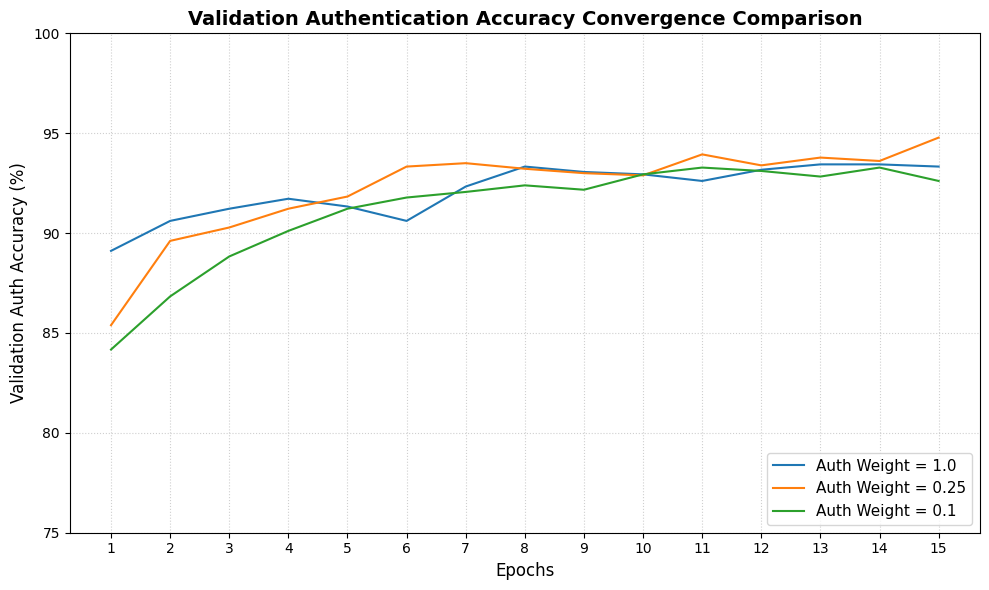

In [ ]:
# 1. Define the epochs (1 to 15)
epochs = list(range(1, 16))

# 2. Validation authentication accuracy
auth_acc_10_10 = [
    89.11, 90.61, 91.22, 91.72, 91.33, 90.61, 92.33,
    93.33, 93.06, 92.94, 92.61, 93.17, 93.44, 93.44, 93.33
]

auth_acc_10_25 = [
    85.39, 89.61, 90.28, 91.22, 91.83, 93.33, 93.50,
    93.22, 93.00, 92.89, 93.94, 93.39, 93.78, 93.61, 94.78
]

auth_acc_10_01 = [
    84.17, 86.83, 88.83, 90.11, 91.22, 91.78, 92.06,
    92.39, 92.17, 92.94, 93.28, 93.11, 92.83, 93.28, 92.61
]

# 3. Create the plot
plt.figure(figsize=(10, 6))

# Plot each line with distinct markers and labels
plt.plot(epochs, auth_acc_10_10, label='Auth Weight = 1.0')
plt.plot(epochs, auth_acc_10_25, label='Auth Weight = 0.25')
plt.plot(epochs, auth_acc_10_01, label='Auth Weight = 0.1')

# 4. Customize the plot aesthetics
plt.title('Validation Authentication Accuracy Convergence Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Validation Auth Accuracy (%)', fontsize=12)
plt.xticks(epochs)
plt.ylim(75, 100)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='lower right')

# 5. Display the plot
plt.tight_layout()
plt.show()

##### Transformation loss

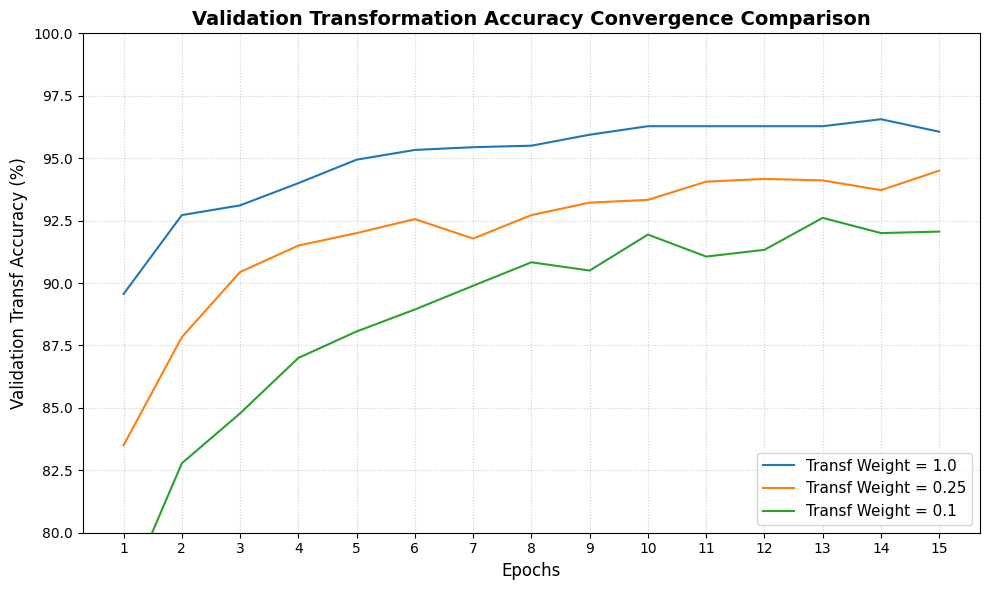

In [ ]:
# 1. Define the epochs (1 to 15)
epochs = list(range(1, 16))

# 2. Validation transformation accuracy
transf_acc_10_10 = [
    89.56, 92.72, 93.11, 94.00, 94.94, 95.33, 95.44,
    95.50, 95.94, 96.28, 96.28, 96.28, 96.28, 96.56, 96.06

]

transf_acc_10_01 = [
    77.33, 82.78, 84.78, 87.00, 88.06, 88.94, 89.89,
    90.83, 90.50, 91.94, 91.06, 91.33, 92.61, 92.00, 92.06
]

transf_acc_10_25 = [
    83.50, 87.83, 90.44, 91.50, 92.00, 92.56, 91.78,
    92.72, 93.22, 93.33, 94.06, 94.17, 94.11, 93.72, 94.50
]

# 3. Create the plot
plt.figure(figsize=(10, 6))

# Plot each line with distinct markers and labels
plt.plot(epochs, transf_acc_10_10, label='Transf Weight = 1.0')
plt.plot(epochs, transf_acc_10_25, label='Transf Weight = 0.25')
plt.plot(epochs, transf_acc_10_01, label='Transf Weight = 0.1')

# 4. Customize the plot aesthetics
plt.title('Validation Transformation Accuracy Convergence Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Validation Transf Accuracy (%)', fontsize=12)
plt.xticks(epochs)
plt.ylim(75, 100)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='lower right')

# 5. Display the plot
plt.tight_layout()
plt.show()

### Baslines

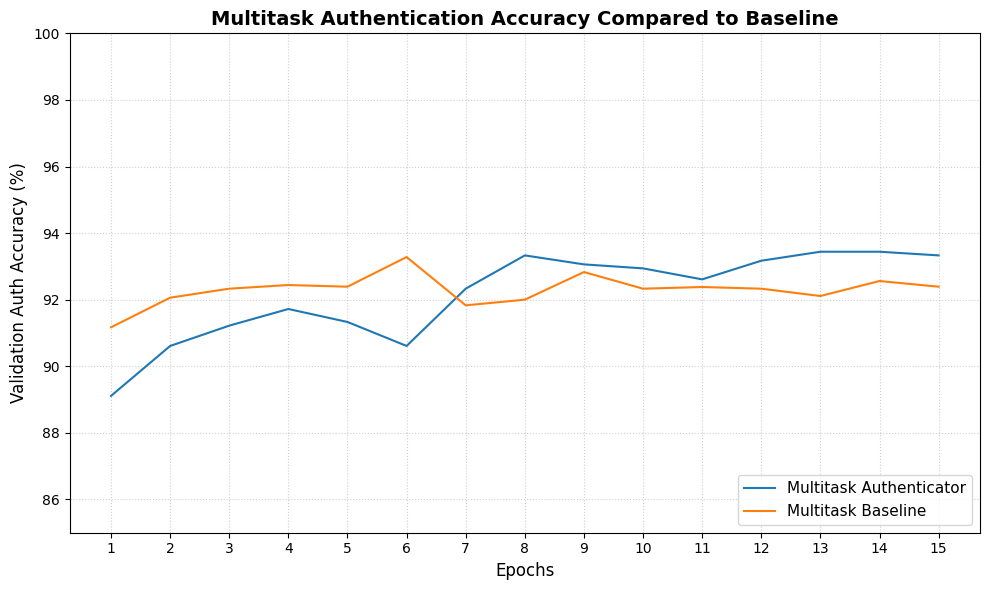

In [ ]:
# 1. Define the epochs (1 to 15)
epochs = list(range(1, 16))

# 2. Validation authentication accuracy
auth_acc_10_10 = [
    89.11, 90.61, 91.22, 91.72, 91.33, 90.61, 92.33,
    93.33, 93.06, 92.94, 92.61, 93.17, 93.44, 93.44, 93.33
]

auth_baseline = [
    91.17, 92.06, 92.33, 92.44, 92.39, 93.28, 91.83,
    92.00, 92.83, 92.33, 92.38, 92.33, 92.11, 92.56, 92.39
]

# 3. Create the plot
plt.figure(figsize=(10, 6))

# Plot each line with distinct markers and labels
plt.plot(epochs, auth_acc_10_10, label='Multitask Authenticator')
plt.plot(epochs, auth_baseline, label='Baseline Authenticator')

# 4. Customize the plot aesthetics
plt.title('Multitask Authentication Accuracy Compared to Baseline', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Validation Auth Accuracy (%)', fontsize=12)
plt.xticks(epochs)
plt.ylim(85, 100)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='lower right')

# 5. Display the plot
plt.tight_layout()
plt.show()

In [ ]:
eval_model = AuthenticatorEfficient().to(device)
model_path = "/content/drive/MyDrive/result_baseline_auth.pth"
checkpoint = torch.load(model_path, map_location=device)
# Load only the model weights
eval_model.load_state_dict(checkpoint["model_state_dict"])


print("Evaluating model: Authenticator Basline")
results_auth = evaluate_predictions_auth(eval_model, test_loader, device)

Evaluating model: Authenticator Basline


Evaluating:   0%|          | 0/113 [00:00<?, ?it/s]

Ai/original accuracy:        92.72%

Ai/original accuracy by transformation type


,true_transform_name,num_samples,auth_accuracy
1,redigital,600,91.333333
0,original,600,92.833333
2,transfer,600,94.000000


Original/ai accuracy by transformation type and true class


,true_transform_name,true_auth_name,num_samples,auth_accuracy
1,original,real,300,91.333333
0,original,ai,300,94.333333
3,redigital,real,300,87.666667
2,redigital,ai,300,95.000000
5,transfer,real,300,90.000000
4,transfer,ai,300,98.000000


========== Pivot Table: Auth Accuracy ==========


true_auth_name,ai,real
true_transform_name,,
original,94.333333,91.333333
redigital,95.000000,87.666667
transfer,98.000000,90.000000


========== Which transformation type makes the real/fake detector perform worst ==========
The lowest real/fake detection accuracy occurs for redigital images: 91.33% accuracy over 600 samples.

========== Real/Fake Confusion Matrix ==========


,Pred real,Pred ai
True real,807,93
True ai,38,862


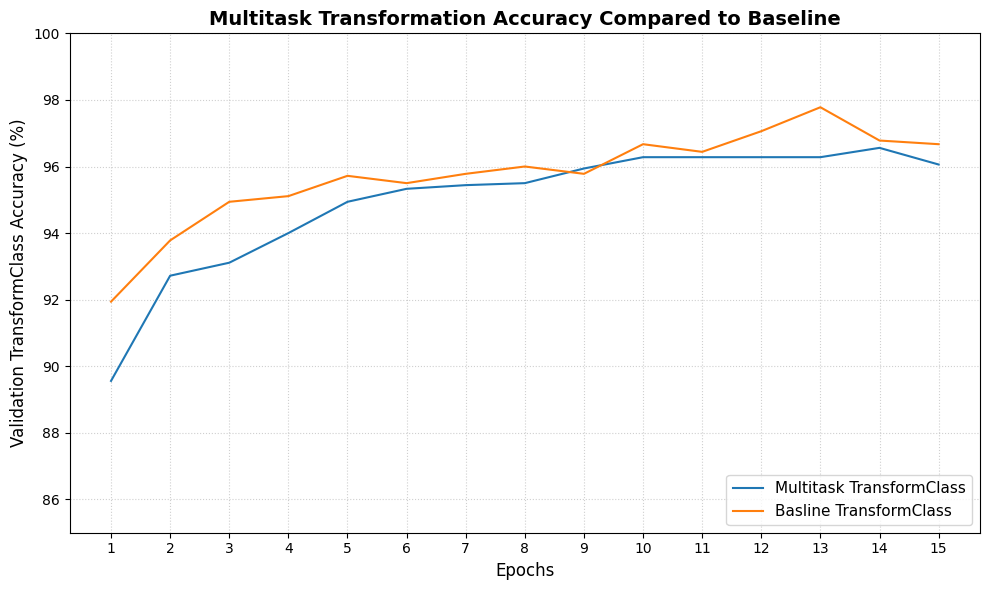

In [2]:
# Transformation
# 1. Define the epochs (1 to 15)
epochs = list(range(1, 16))

# 2. Validation transformation accuracy
transf_acc_10_10 = [
    89.56, 92.72, 93.11, 94.00, 94.94, 95.33, 95.44,
    95.50, 95.94, 96.28, 96.28, 96.28, 96.28, 96.56, 96.06

]

transf_baseline = [
    91.94, 93.78, 94.94, 95.11, 95.72, 95.50, 95.78,
    96.00, 95.78, 96.67, 96.44, 97.06, 97.78, 96.78, 96.67
]

# 3. Create the plot
plt.figure(figsize=(10, 6))

# Plot each line with distinct markers and labels
plt.plot(epochs, transf_acc_10_10,  label='Multitask TransformClass')
plt.plot(epochs, transf_baseline,   label='Basline TransformClass')

# 4. Customize the plot aesthetics
plt.title('Multitask Transformation Accuracy Compared to Baseline', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Validation TransformClass Accuracy (%)', fontsize=12)
plt.xticks(epochs)
plt.ylim(85, 100)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='lower right')

# 5. Display the plot
plt.tight_layout()
plt.show()

In [ ]:
eval_model = TransformClassifierEfficient().to(device)
model_path = "/content/drive/MyDrive/result_baseline_transform.pth"
checkpoint = torch.load(model_path, map_location=device)
# Load only the model weights
eval_model.load_state_dict(checkpoint["model_state_dict"])


print("Evaluating model: Authenticator Basline")
results_auth = evaluate_predictions_trans(eval_model, test_loader, device)

Evaluating model: Authenticator Basline


Evaluating:   0%|          | 0/113 [00:00<?, ?it/s]

Overall accuracy 
Transformation accuracy:   97.44%

========== Transformation Confusion Matrix ==========


,Pred original,Pred transfer,Pred redigital
True original,586,10,4
True transfer,18,582,0
True redigital,13,1,586


========== Transformation Confusion Matrix (Normalized) ==========


,Pred original,Pred transfer,Pred redigital
True original,0.976667,0.016667,0.006667
True transfer,0.030000,0.970000,0.000000
True redigital,0.021667,0.001667,0.976667


#### Evaluating Multitask Models

#### 1. Evaluating w_auth = 1, w_trans = 1

In [ ]:
eval_model = MultiTaskDetectorEfficient().to(device)
model_path = "/content/drive/MyDrive/best_efficientnet_model_1.0_1.0.pth"
checkpoint = torch.load(model_path, map_location=device)
# Load only the model weights
eval_model.load_state_dict(checkpoint["model_state_dict"])


print("Evaluating model: w_auth = 1.0, w_trans = 1.0")
results_10_10 = evaluate_predictions(eval_model, test_loader, device)

Evaluating model: w_auth = 1.0, w_trans = 1.0


Evaluating:   0%|          | 0/113 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Overall accuracy 
Ai/original accuracy:        94.22%
Transformation accuracy:   97.06%

Ai/original accuracy by transformation type


,true_transform_name,num_samples,auth_accuracy
1,redigital,600,92.666667
2,transfer,600,94.500000
0,original,600,95.500000


...

,Pred real,Pred ai
True real,829,71
True ai,33,867


========== Transformation Confusion Matrix ==========


,Pred original,Pred transfer,Pred redigital
True original,579,15,6
True transfer,20,580,0
True redigital,12,0,588


========== Transformation Confusion Matrix (Normalized) ==========


,Pred original,Pred transfer,Pred redigital
True original,0.965000,0.025000,0.01
True transfer,0.033333,0.966667,0.00
True redigital,0.020000,0.000000,0.98


#### 2. Evaluating w_auth = 0.25, w_trans = 1


In [ ]:
eval_model = MultiTaskDetectorEfficient().to(device)
model_path = "/content/drive/MyDrive/best_efficientnet_model_0.25_1.0.pth"
checkpoint = torch.load(model_path, map_location=device)
# Load only the model weights into your architecture
eval_model.load_state_dict(checkpoint["model_state_dict"])


print("Evaluating model: w_auth = 0.25, w_trans = 1.0")
results_25_10 = evaluate_predictions(eval_model, test_loader, device)

Evaluating model: w_auth = 0.25, w_trans = 1.0


Evaluating:   0%|          | 0/113 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Overall accuracy 
Ai/original accuracy:        93.72%
Transformation accuracy:   97.39%

Ai/original accuracy by transformation type


,true_transform_name,num_samples,auth_accuracy
1,redigital,600,92.500000
2,transfer,600,94.000000
0,original,600,94.666667


...

,Pred real,Pred ai
True real,837,63
True ai,50,850


========== Transformation Confusion Matrix ==========


,Pred original,Pred transfer,Pred redigital
True original,584,13,3
True transfer,23,577,0
True redigital,8,0,592


========== Transformation Confusion Matrix (Normalized) ==========


,Pred original,Pred transfer,Pred redigital
True original,0.973333,0.021667,0.005000
True transfer,0.038333,0.961667,0.000000
True redigital,0.013333,0.000000,0.986667


#### 3. Evaluating w_auth = 0.1, w_trans = 1.0

In [ ]:
# TO DO RUN
eval_model = MultiTaskDetectorEfficient().to(device)
model_path = "/content/drive/MyDrive/best_efficientnet_model_0.10_1.0.pth"
checkpoint = torch.load(model_path, map_location=device)
# Load only the model weights
eval_model.load_state_dict(checkpoint["model_state_dict"])


print("Evaluating model: w_auth = 0.1, w_trans = 1.0")
results_01_10 = evaluate_predictions(eval_model, test_loader, device)

Evaluating model: w_auth = 0.1, w_trans = 1.0


Evaluating:   0%|          | 0/113 [00:00<?, ?it/s]

Overall accuracy 
Ai/original accuracy:        94.83%
Transformation accuracy:   98.28%

Ai/original accuracy by transformation type


,true_transform_name,num_samples,auth_accuracy
2,transfer,600,94.333333
1,redigital,600,94.500000
0,original,600,95.666667


Original/ai accuracy by transformation type and true class


...

,Pred real,Pred ai
True real,832,68
True ai,25,875


========== Transformation Confusion Matrix ==========


,Pred original,Pred transfer,Pred redigital
True original,591,7,2
True transfer,13,587,0
True redigital,9,0,591


========== Transformation Confusion Matrix (Normalized) ==========


,Pred original,Pred transfer,Pred redigital
True original,0.985000,0.011667,0.003333
True transfer,0.021667,0.978333,0.000000
True redigital,0.015000,0.000000,0.985000


#### 4. Evaluating w_auth = 1.0, w_trans = 0.25



In [ ]:
eval_model = MultiTaskDetectorEfficient().to(device)
model_path = "/content/drive/MyDrive/best_efficientnet_model_1.0_0.25.pth"
checkpoint = torch.load(model_path, map_location=device)
# Load only the model weights
eval_model.load_state_dict(checkpoint["model_state_dict"])


print("Evaluating model: w_auth = 1.0, w_trans = 0.25")
results_10_25 = evaluate_predictions(eval_model, test_loader, device)

Evaluating model: w_auth = 1.0, w_trans = 0.25


Evaluating:   0%|          | 0/113 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Overall accuracy 
Ai/original accuracy:        94.06%
Transformation accuracy:   94.28%

Ai/original accuracy by transformation type


,true_transform_name,num_samples,auth_accuracy
1,redigital,600,93.166667
0,original,600,94.500000
2,transfer,600,94.500000


...

,Pred real,Pred ai
True real,835,65
True ai,42,858


========== Transformation Confusion Matrix ==========


,Pred original,Pred transfer,Pred redigital
True original,568,17,15
True transfer,49,549,2
True redigital,20,0,580


========== Transformation Confusion Matrix (Normalized) ==========


,Pred original,Pred transfer,Pred redigital
True original,0.946667,0.028333,0.025000
True transfer,0.081667,0.915000,0.003333
True redigital,0.033333,0.000000,0.966667


#### 5. Evaluating w_auth = 1.0, w_trans = 0.10



In [ ]:
# TO DO RUN
eval_model = MultiTaskDetectorEfficient().to(device)
model_path = "/content/drive/MyDrive/best_efficientnet_model_1.0_0.10.pth"
checkpoint = torch.load(model_path, map_location=device)
# Load only the model weights
eval_model.load_state_dict(checkpoint["model_state_dict"])


print("Evaluating model: w_auth = 1.0, w_trans = 0.10")
results_10_01 = evaluate_predictions(eval_model, test_loader, device)

Evaluating model: w_auth = 1.0, w_trans = 0.10


Evaluating:   0%|          | 0/113 [00:00<?, ?it/s]

Overall accuracy 
Ai/original accuracy:        94.06%
Transformation accuracy:   88.61%

Ai/original accuracy by transformation type


,true_transform_name,num_samples,auth_accuracy
1,redigital,600,92.833333
0,original,600,94.333333
2,transfer,600,95.000000


Original/ai accuracy by transformation type and true class


...

,Pred real,Pred ai
True real,797,103
True ai,4,896


========== Transformation Confusion Matrix ==========


,Pred original,Pred transfer,Pred redigital
True original,552,17,31
True transfer,75,522,3
True redigital,78,1,521


========== Transformation Confusion Matrix (Normalized) ==========


,Pred original,Pred transfer,Pred redigital
True original,0.920,0.028333,0.051667
True transfer,0.125,0.870000,0.005000
True redigital,0.130,0.001667,0.868333


# Discussion

### 1 Performance analysis across transformation types


### 2 Ablation Study
Our hypothesis was that, in the multi-task learning setting, reducing the loss weight assigned to a specific task would weaken that task’s contribution to the overall optimization objective and may therefore lead to lower performance on that task. This expectation is based on the fact that the total objective is formulated as a weighted combination of task-specific losses, meaning that the relative loss weights influence the optimization priority given to each task, as discussed by Kendall et al. (2018). However, we also hypothesized that this relationship would not necessarily be strictly monotonic, since the two tasks may either compete for shared representational capacity or benefit from shared feature learning.

### 3 Lowering the transformation loss

| $w_{\text{AI/original}}$ | $w_{\text{transform}}$ | AI/original Accuracy | Transformation Accuracy |
| -----------------------: | ---------------------: | -------------------: | ----------------------: |
|                     1.00 |                   1.00 |               94.22% |                  97.06% |
|                     1.00 |                   0.25 |               94.06% |                  94.28% |
|                     1.00 |                   0.10 |               94.06% |                  88.61% |

Table 1: Effect of reducing the transformation loss weight while keeping the AI/original loss weight fixed.

The results shown in Table 1 support our hypothesis that reducing the loss weight assigned to a task can weaken its optimization priority and lead to lower performance on that task. In Table 1, decreasing the transformation loss weight from 1.00 to 0.25 and then to 0.10 leads to a clear drop in transformation accuracy, from 97.06% to 94.28% and 88.61%, respectively. Meanwhile, AI/original accuracy remains nearly unchanged, suggesting that reducing the auxiliary transformation loss mainly affects the transformation classification branch rather than substantially improving or degrading the AI/original task.

| $w_{\text{trans}}$ | Worst transformation type | AI/original accuracy |
| -----------------: | ------------------------- | -------------------: |
|               1.00 | redigital                 |               92.67% |
|               0.25 | redigital                 |               93.17% |
|               0.10 | redigital                 |               92.83% |

Table 2: Worst transformation type while reducing the transformation loss weight while keeping the AI/original loss weight fixed.

Table 2 shows that across all loss-weight configurations, re-digitalized images produced the lowest AI/original classification accuracy, suggesting that the re-digitization process introduces degradation patterns that make authenticity detection more difficult.

### 4 Lowering the authenticity

The results shown below in Table 3 do not support the hypothesis. Reducing the AI/original loss weight did not harm AI/original classification.

| $w_{\text{auth}}$ | AI/original Accuracy |
| ----------------: | -------------------: |
|              1.00 |               94.22% |
|              0.25 |               93.72% |
|              0.10 |               94.83% |

Table 3: Effect of reducing the authenticity loss weight while keeping the transformation loss weight fixed.

The improvement at $w_{\text{auth}} = 0.10$ suggests that AI/original classification may benefit from features learned through the transformation task.

| $w_{\text{auth}}$ | Transformation Accuracy |
| ----------------: | ----------------------: |
|              1.00 |                  97.06% |
|              0.25 |                  97.39% |
|              0.10 |                  98.28% |

Table 4: Increase of transformation accuracy when $w_{\text{auth}}$ drops.

Table 4 supports the idea that reducing the competing task's weight allows the model to focus more on transformation classification.

### 5 Conclusion

The ablation study shows that the effect of loss weighting is not strictly monotonic. Lowering the transformation loss weight clearly reduced transformation accuracy, which supports the hypothesis that giving a task less weight can weaken its optimization priority. However, lowering the AI/original loss weight did not reduce AI/original accuracy and even slightly improved it in the lowest-weight setting.

This suggests that AI/original detection benefits from the transformation-related features learned by the shared backbone. Therefore, the hypothesis is only partially supported: loss weighting affects task performance, but the direction and strength of this effect depend on how much the tasks share useful representations.

# Bibliography

Contributors, P. (2023, January 1). Training with PyTorch. https://docs.pytorch.org/tutorials/beginner/introyt/trainingyt.html​

​
Yosinski, J., Clune, J., Bengio, Y., & Lipson, H. (2014, November 6). How transferable are features in deep neural networks?arXiv.org. https://arxiv.org/abs/1411.1792​

​
efficientnet_b4 — Torchvision main documentation. (n.d.). https://docs.pytorch.org/vision/main/models/generated/torchvision.models.efficientnet_b4.html​

​
Finetuning Torchvision Models — PyTorch Tutorials 1.0.0.dev20181128 documentation. (n.d.). https://brsoff.github.io/tutorials/beginner/finetuning_torchvision_models_tutorial.html\​


Kendall, A., Gal, Y., & Cipolla, R. (2018). Multi-Task Learning Using Uncertainty to Weigh Losses for Scene Geometry and Semantics. Retrieved June 12, 2026, from https://openaccess.thecvf.com/content_cvpr_2018/papers/Kendall_Multi-Task_Learning_Using_CVPR_2018_paper.pdf

​
Shafiq, M. T., & Pratap, V. (2026). Detection of AI-Generated Images using EfficientNet: A step toward Computational efficiency. In Lecture notes in networks and systems (pp. 191–197). https://doi.org/10.1007/978-981-96-7526-5_23​​